In [12]:
!pip install timm -q

import os
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn, optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
DATA_DIR = "/kaggle/input/datasets/venkatsaikondra/venkatsaikondra67/Final_Data"  # change this

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

In [14]:
train_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
])

In [15]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR, transform=val_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR, transform=val_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [16]:
targets = [label for _, label in train_dataset]
class_count = np.bincount(targets)

weights = 1. / class_count
sample_weights = [weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [17]:
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [18]:
model = timm.create_model('tf_efficientnet_b4', pretrained=True, num_classes=num_classes)
model.to(device)

EfficientNet(
  (conv_stem): Conv2dSame(3, 48, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
        (bn1): BatchNormAct2d(
          48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNo

In [19]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=3e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

In [20]:
def train_model(epochs=30):

    scaler = torch.cuda.amp.GradScaler()
    best_f1 = 0

    for epoch in range(epochs):

        # 🔹 TRAIN
        model.train()
        total_loss, total_samples = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)

        train_loss = total_loss / total_samples

        # 🔹 VALIDATION
        model.eval()
        preds_all, labels_all = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                outputs = model(images)
                preds = torch.argmax(outputs, dim=1)

                preds_all.extend(preds.cpu().numpy())
                labels_all.extend(labels.numpy())

        val_f1 = f1_score(labels_all, preds_all, average='macro')

        scheduler.step()

        # 🔹 SAVE BEST
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_efficientnet_b4.pth")

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val F1: {val_f1:.4f}")
        print(f"Best F1: {best_f1:.4f}")
        print("-"*50)

    print("✅ Training Complete")

In [21]:
train_model(epochs=30)

/tmp/ipykernel_55/299708095.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/299708095.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/30]
Train Loss: 0.7974
Val F1: 0.8647
Best F1: 0.8647
--------------------------------------------------


/tmp/ipykernel_55/299708095.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [2/30]
Train Loss: 0.5999
Val F1: 0.7895
Best F1: 0.8647
--------------------------------------------------


/tmp/ipykernel_55/299708095.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch [28/30]
Train Loss: 0.3511
Val F1: 0.9542
Best F1: 0.9548
--------------------------------------------------


/tmp/ipykernel_55/299708095.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [29/30]
Train Loss: 0.3505
Val F1: 0.9541
Best F1: 0.9548
--------------------------------------------------


/tmp/ipykernel_55/299708095.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [30/30]
Train Loss: 0.3503
Val F1: 0.9542
Best F1: 0.9548
--------------------------------------------------
✅ Training Complete


In [22]:
model.load_state_dict(torch.load("best_efficientnet_b4.pth", map_location=device))
model.eval()

EfficientNet(
  (conv_stem): Conv2dSame(3, 48, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
        (bn1): BatchNormAct2d(
          48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNo

In [23]:
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

f1 = f1_score(all_labels, all_preds, average='macro')

print("🔥 TEST F1:", f1)
print(classification_report(all_labels, all_preds, target_names=class_names))

🔥 TEST F1: 0.9480695543812627
                     precision    recall  f1-score   support

           Covid-19       1.00      1.00      1.00       405
             Normal       0.99      0.99      0.99       405
Pneumonia-Bacterial       0.92      0.89      0.91       405
    Pneumonia-Viral       0.90      0.91      0.90       405

           accuracy                           0.95      1620
          macro avg       0.95      0.95      0.95      1620
       weighted avg       0.95      0.95      0.95      1620



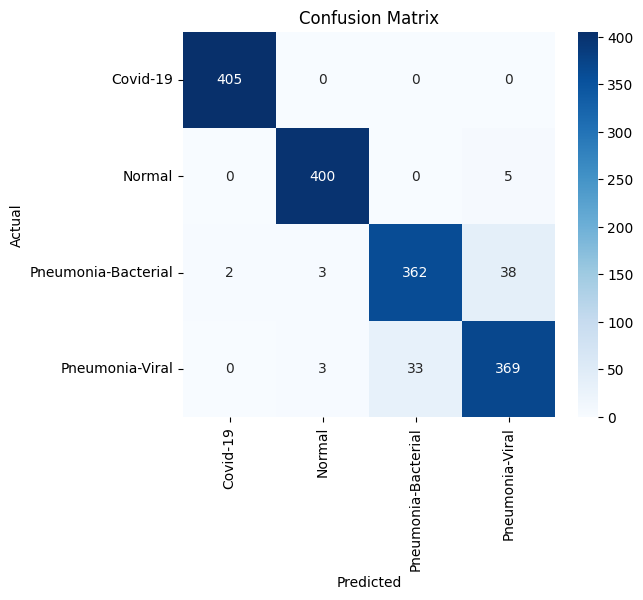

In [24]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

In [30]:
y_true = all_labels.numpy()
y_score = all_probs.numpy()

num_classes = y_score.shape[1]

In [31]:
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

In [32]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

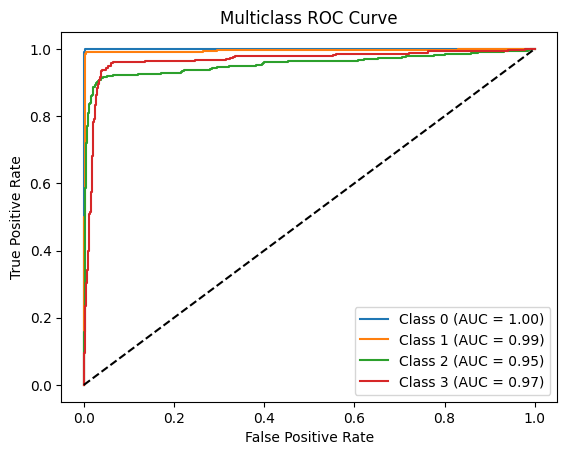

In [33]:
plt.figure()

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()

In [34]:
!pip install grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.2 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=0d490895df5af09d910e71a2d5db45c4c3c776477d04774481a49a0cb8d6146f
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [37]:
target_layer = model.blocks[-1]

In [45]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

cam = GradCAM(model=model, target_layers=[target_layer])

image, label = next(iter(test_loader))
input_tensor = image[0:1].to(device)

targets = [ClassifierOutputTarget(label[0].item())]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

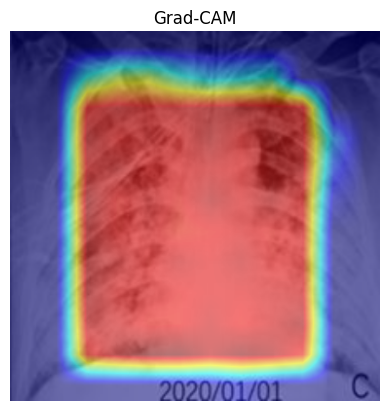

In [46]:
img = input_tensor.squeeze().permute(1,2,0).cpu().numpy()
img = (img - img.min()) / (img.max() - img.min())

visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.axis('off')
plt.title("Grad-CAM")
plt.show()

In [51]:
import numpy as np
import torch
import torch.nn.functional as F

class RISE:
    def __init__(self, model, input_size, device):
        self.model = model
        self.input_size = input_size
        self.device = device

    def generate_masks(self, N, s, p1):
        cell_size = np.ceil(np.array(self.input_size) / s)
        up_size = (s + 1) * cell_size

        masks = []
        for _ in range(N):
            grid = (np.random.rand(s, s) < p1).astype(float)
            mask = torch.tensor(grid).float()

            mask = F.interpolate(
                mask.unsqueeze(0).unsqueeze(0),
                size=tuple(up_size.astype(int)),
                mode='bilinear',
                align_corners=False
            )

            x = np.random.randint(0, cell_size[0])
            y = np.random.randint(0, cell_size[1])

            mask = mask[:, :, :self.input_size[0], :self.input_size[1]]
            masks.append(mask)

        masks = torch.cat(masks, dim=0)
        return masks.to(self.device)

    def explain(self, image, masks, batch_size=16):  # smaller batch for safety
        N = masks.size(0)
        _, _, H, W = image.size()

        saliency = torch.zeros((H, W)).to(self.device)

        for i in range(0, N, batch_size):
            batch_masks = masks[i:i+batch_size]

            # repeat image for batch
            batch_image = image.repeat(batch_masks.size(0), 1, 1, 1)

            masked = batch_image * batch_masks

            with torch.no_grad():
                preds = self.model(masked)
                probs = torch.softmax(preds, dim=1)

            for j in range(batch_masks.size(0)):
                saliency += probs[j, 1] * batch_masks[j, 0]

        saliency /= N
        return saliency.cpu().numpy()

In [52]:
rise = rise = RISE(model, input_size=(380, 380), device=device)

image, _ = next(iter(test_loader))
input_tensor = image[0:1].to(device)

masks = rise.generate_masks(N=2000, s=8, p1=0.5)
saliency_map = rise.explain(input_tensor, masks)

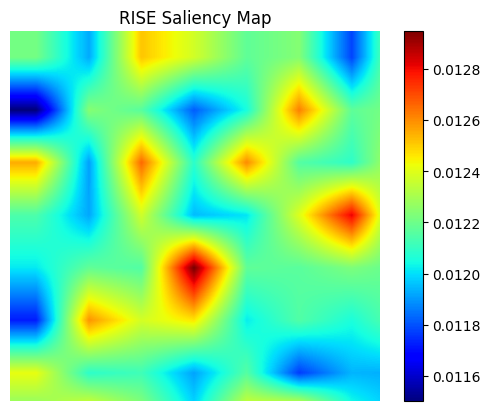

In [53]:
plt.imshow(saliency_map, cmap='jet')
plt.colorbar()
plt.title("RISE Saliency Map")
plt.axis('off')
plt.show()